# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Mahardika Indra Pratama Ilyasa | 5054251045|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [92]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, auc,
                             roc_curve, roc_auc_score)


In [93]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
data = pd.read_csv('sample_data/mushrooms.csv')
display(data.head())
data.info()
data.describe(include='object')


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [94]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print(f"Bentuk dataset (baris, kolom): {data.shape}")
print("\nTipe data dan info kolom:")
data.info()

print("\nJumlah missing value (pandas):")
print(data.isnull().sum())

print(f"\nJumlah '?' pada kolom stalk-root: {(data['stalk-root'] == '?').sum()}")

Bentuk dataset (baris, kolom): (8124, 23)

Tipe data dan info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-sur

In [95]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
print("Jumlah nilai unik per kolom:")
print(data.nunique())

single_val_cols = [col for col in data.columns if data[col].nunique() == 1]
print(f"\nKolom dengan hanya 1 nilai unik: {single_val_cols}")

Jumlah nilai unik per kolom:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

Kolom dengan hanya 1 nilai unik: ['veil-type']


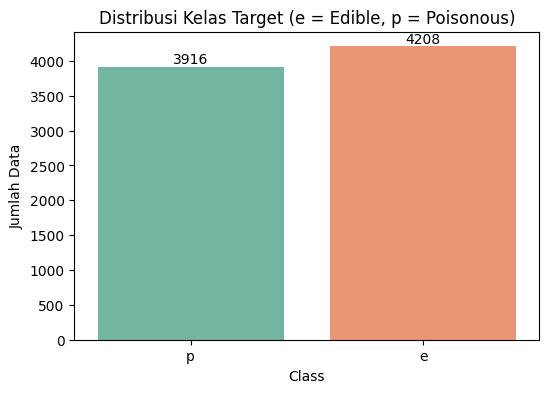

Persentase distribusi target:
class
e    51.797144
p    48.202856
Name: proportion, dtype: float64
Selisih:  292
Selisih Percent: 3.59 %


In [96]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x="class", hue="class", palette="Set2", legend=False)
plt.title("Distribusi Kelas Target (e = Edible, p = Poisonous)")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()

print("Persentase distribusi target:")
print(data["class"].value_counts(normalize=True) * 100)
_dif = data['class'].value_counts().iloc[0] - data['class'].value_counts().iloc[1]
print("Selisih: ", _dif)
print("Selisih Percent:", round(_dif / len(data) * 100, 2), "%")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [97]:
# Analisis hubungan setiap fitur kategorikal dengan class
# Menggunakan Chi-Square dan Mutual Information

eda_data = data.copy()

eda_data["class_num"] = eda_data["class"].map({"e": 0, "p": 1})

feature_cols = [col for col in eda_data.columns
                if col not in ["class", "class_num"]]

hasil_eda = []

for col in feature_cols:
    contingency_table = pd.crosstab(eda_data[col], eda_data["class_num"])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    X_feature = pd.factorize(eda_data[col])[0].reshape(-1, 1)
    mi = mutual_info_classif(
        X_feature,
        eda_data["class_num"],
        discrete_features=True,
        random_state=42
    )[0]

    hasil_eda.append({
        "Feature": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Mutual Information": mi
    })

hasil_eda = pd.DataFrame(hasil_eda)

hasil_eda = hasil_eda.sort_values(
    by="Mutual Information",
    ascending=False
).reset_index(drop=True)

hasil_eda

,Feature,Chi-Square,p-value,Mutual Information
0,odor,7659.726740,0.000000e+00,0.628043
1,spore-print-color,4602.033170,0.000000e+00,0.333199
2,gill-color,3765.714086,0.000000e+00,0.289027
3,ring-type,2956.619278,0.000000e+00,0.220436
4,stalk-surface-above-ring,2808.286287,0.000000e+00,0.197357
5,stalk-surface-below-ring,2684.474076,0.000000e+00,0.188463
6,stalk-color-above-ring,2237.898496,0.000000e+00,0.175952
7,stalk-color-below-ring,2152.390891,0.000000e+00,0.167337
8,gill-size,2366.834257,0.000000e+00,0.159531
9,population,1929.740891,0.000000e+00,0.139987


Berdasarkan hasil perhitungan Normalized Mutual Information (NMI), dapat diambil kesimpulan bahwa fitur `odor` memiliki tingkat efektivitas tertinggi dalam mengidentifikasi kelas jamur, dengan nilai NMI sebesar 0,6280. Selanjutnya, akan diambil 7 fitur teratas untuk pemodelan, yaitu: `odor`, `spore-print-color`, `gill-color`, `ring-type`, `stalk-surface-above-ring`, `stalk-surface-below-ring`, dan `stalk-color-above-ring`.

In [98]:
# Analisis hubungan setiap fitur kategorikal dengan class
# Menggunakan Chi-Square dan Normalized Mutual Information (NMI)
eda_data = data.copy()
eda_data["class_num"] = eda_data["class"].map({"e": 0, "p": 1})

feature_cols = [col for col in eda_data.columns if col not in ["class", "class_num"]]

hasil_eda = []

for col in feature_cols:
    # 1. Chi-Square
    contingency_table = pd.crosstab(eda_data[col], eda_data["class_num"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # 2. Normalized Mutual Information (NMI)
    nmi = normalized_mutual_info_score(eda_data[col], eda_data["class_num"])

    hasil_eda.append({
        "Feature": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "NMI": nmi
    })

hasil_eda = pd.DataFrame(hasil_eda)

hasil_eda = hasil_eda.sort_values(by="NMI", ascending=False).reset_index(drop=True)

display(hasil_eda)

,Feature,Chi-Square,p-value,NMI
0,odor,7659.726740,0.000000e+00,0.546078
1,spore-print-color,4602.033170,0.000000e+00,0.300225
2,stalk-surface-above-ring,2808.286287,0.000000e+00,0.256462
3,ring-type,2956.619278,0.000000e+00,0.250985
4,gill-size,2366.834257,0.000000e+00,0.243379
5,stalk-surface-below-ring,2684.474076,0.000000e+00,0.226749
6,gill-color,3765.714086,0.000000e+00,0.206962
7,bruises,2041.415647,0.000000e+00,0.194480
8,stalk-color-above-ring,2237.898496,0.000000e+00,0.172926
9,stalk-color-below-ring,2152.390891,0.000000e+00,0.162175


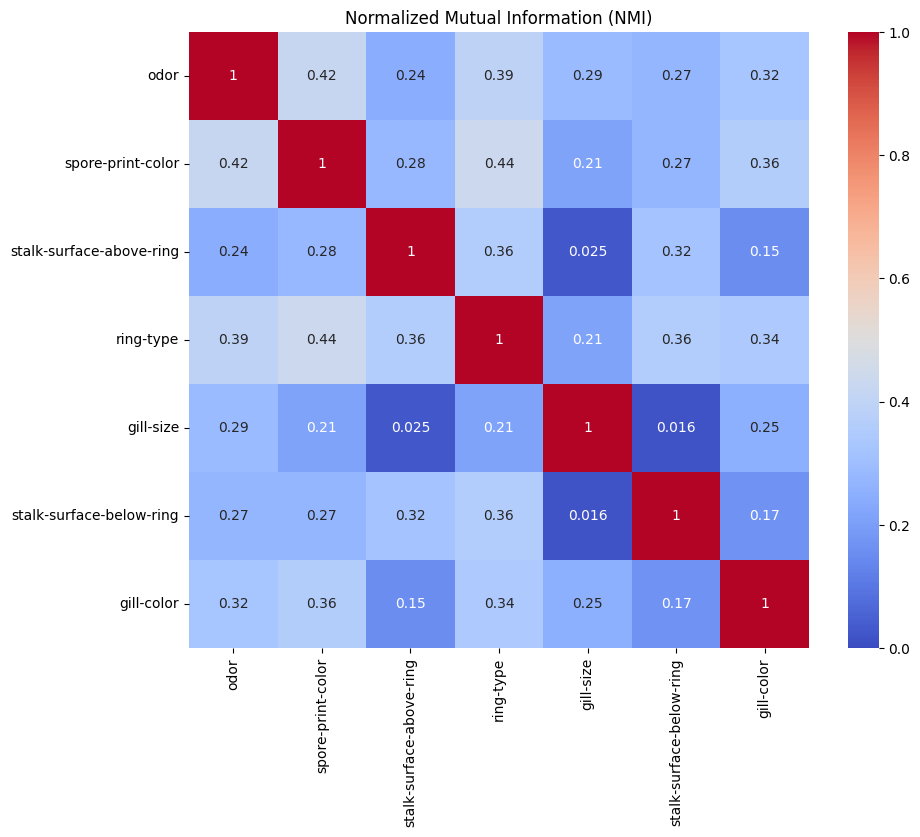

Fitur yang dibuang karena saling tumpang tindih (NMI > 0.4): {'ring-type', 'spore-print-color'}
Fitur yang dipertahankan: ['odor', 'stalk-surface-above-ring', 'gill-size', 'stalk-surface-below-ring', 'gill-color']


In [99]:
# Mengambil Top 7 fitur berdasarkan NMI tertinggi
top_7 = hasil_eda.head(7)["Feature"].tolist()

mi_matrix = pd.DataFrame(index=top_7, columns=top_7)

for c1 in top_7:
    for c2 in top_7:
        mi_matrix.loc[c1, c2] = normalized_mutual_info_score(data[c1], data[c2])

mi_matrix = mi_matrix.astype(float)

# Visualisasi matriks
plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Normalized Mutual Information (NMI)")
plt.show()

# Hapus fitur yang informasinya terlalu identik / tumpang tindih (NMI > 0.4)
threshold = 0.4
to_drop = set()

for i in range(len(mi_matrix.columns)):
    for j in range(i):
        if mi_matrix.iloc[i, j] > threshold:
            colname = mi_matrix.columns[i]
            to_drop.add(colname)

print(f"Fitur yang dibuang karena saling tumpang tindih (NMI > {threshold}): {to_drop}")

# Filter fitur
selected_features = [f for f in top_7 if f not in to_drop]
print(f"Fitur yang dipertahankan: {selected_features}")

Berdasarkan matriks NMI, terdapat beberapa fitur yang saling tumpang tindih informasinya `ring-type`, `spore-print-color` (> 0,4). Oleh karena itu, fitur-fitur tersebut perlu dihapus untuk menghindari pelanggaran asumsi independensi pada model Naive Bayes.

In [116]:
for feat in ["ring-type", "spore-print-color"]:
    if feat in selected_features:
        selected_features.remove(feat)

print(f"Fitur yang dipilih: {selected_features}")

Fitur yang dipilih: ['odor', 'stalk-surface-above-ring', 'gill-size', 'stalk-surface-below-ring', 'gill-color']


In [117]:
rare_categories_info = []

for col in selected_features:
    print(f"=== Frekuensi Kategori Kolom: {col} ===")

    # Hitung jumlah dan persentase
    counts = data[col].value_counts()
    percentages = data[col].value_counts(normalize=True) * 100

    # Buat DataFrame frekuensi
    freq_df = pd.DataFrame({'Jumlah': counts, 'Persentase (%)': percentages.round(2)})
    display(freq_df)

    # Cek jika ada kategori langka (< 1%)
    rare = freq_df[freq_df['Persentase (%)'] < 1.0].index.tolist()
    if rare:
        print(f"--> Kategori Langka (< 1%): {rare}")
        rare_categories_info.append((col, rare))

    print("-" * 50 + "\n")

# Hapus baris yang mengandung kategori langka
data_filtered = data.copy()
for col, rare_cats in rare_categories_info:
    data_filtered = data_filtered[~data_filtered[col].isin(rare_cats)]

print(f"Jumlah baris data SEBELUM penghapusan : {data.shape[0]}")
print(f"Jumlah baris data SETELAH penghapusan : {data_filtered.shape[0]}")

data = data_filtered.copy()

=== Frekuensi Kategori Kolom: odor ===


,Jumlah,Persentase (%)
odor,,
n,3416,42.83
f,2160,27.08
y,576,7.22
s,576,7.22
a,400,5.02
l,400,5.02
p,256,3.21
c,192,2.41


--------------------------------------------------

=== Frekuensi Kategori Kolom: stalk-surface-above-ring ===


,Jumlah,Persentase (%)
stalk-surface-above-ring,,
s,5088,63.79
k,2336,29.29
f,552,6.92


--------------------------------------------------

=== Frekuensi Kategori Kolom: gill-size ===


...

--------------------------------------------------

=== Frekuensi Kategori Kolom: stalk-surface-below-ring ===


,Jumlah,Persentase (%)
stalk-surface-below-ring,,
s,4848,60.78
k,2304,28.89
f,600,7.52
y,224,2.81


--------------------------------------------------

=== Frekuensi Kategori Kolom: gill-color ===


,Jumlah,Persentase (%)
gill-color,,
b,1728,21.66
p,1492,18.71
w,1164,14.59
n,1048,13.14
g,752,9.43
h,732,9.18
u,492,6.17
k,408,5.12
e,96,1.20


--> Kategori Langka (< 1%): ['y']
--------------------------------------------------

Jumlah baris data SEBELUM penghapusan : 7976
Jumlah baris data SETELAH penghapusan : 7912


Fitur-fitur terpilih dipastikan telah bebas dari nilai `?`. Namun, ditemukan beberapa kategori langka (< 1%) yang harus dihapus agar tidak mengacaukan perhitungan probabilitas Naive Bayes, yaitu:
* **`odor`**: `['m']`
* **`stalk-surface-above-ring`**: `['y']`
* **`gill-color`**: `['o', 'r']`

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [102]:
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
# '?' dijadikan kategori tersendiri
data["stalk-root"] = data["stalk-root"].replace("?", "m")

print("Distribusi stalk-root setelah penanganan missing value:")
print(data["stalk-root"].value_counts())
# Mengecek jumlah nilai '?'
missing_stalk_root = (data["stalk-root"] == "?").sum()

Distribusi stalk-root setelah penanganan missing value:
stalk-root
b    3736
m    2416
e    1120
c     512
r     192
Name: count, dtype: int64


In [103]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
constant_cols = [col for col in data.columns if data[col].nunique() == 1]
print(f"Kolom tanpa variasi: {constant_cols}")

# Drop kolom veil-type karena tidak memberikan informasi
data = data.drop(columns=constant_cols)
print(f"Jumlah kolom tersisa: {data.shape[1]}")

Kolom tanpa variasi: ['veil-type']
Jumlah kolom tersisa: 22


In [104]:
# Pisahkan fitur (X) dan target (y).
# PERBAIKAN: Gunakan hanya fitur-fitur terbaik yang sudah diseleksi
# Bagi data menjadi train set dan test set (80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data[selected_features]
y = data["class"].map({"e": 0, "p": 1})


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran Train: {X_train.shape}, Ukuran Test: {X_test.shape}")
print(f"Proporsi target pada Train: {y_train.mean():.4f}")
print(f"Proporsi target pada Test: {y_test.mean():.4f}")

Ukuran Train: (6380, 5), Ukuran Test: (1596, 5)
Proporsi target pada Train: 0.4824
Proporsi target pada Test: 0.4825


In [105]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_cat = oe.fit_transform(X_train)
X_test_cat = oe.transform(X_test)

print(f"Bentuk matriks Categorical (Train): {X_train_cat.shape}")

Bentuk matriks Categorical (Train): (6380, 5)


In [106]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

ohe = OneHotEncoder(handle_unknown="ignore")
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

print("Shape X_train:", X_train_ohe.shape)
print("Shape X_test :", X_test_ohe.shape)
print("Tipe data   :", type(X_train_ohe))

Shape X_train: (6380, 27)
Shape X_test : (1596, 27)
Tipe data   : <class 'scipy.sparse._csr.csr_matrix'>


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [107]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cat_nb = CategoricalNB()
cat_nb.fit(X_train_cat, y_train)

CategoricalNB()

In [108]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cat = cat_nb.predict(X_test_cat)
y_prob_cat = cat_nb.predict_proba(X_test_cat)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [109]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bern_nb = BernoulliNB()
bern_nb.fit(X_train_ohe, y_train)

BernoulliNB()

In [110]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bern = bern_nb.predict(X_test_ohe)
y_prob_bern = bern_nb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [111]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
multi_nb = MultinomialNB()
multi_nb.fit(X_train_ohe, y_train)

MultinomialNB()

In [112]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_multi = multi_nb.predict(X_test_ohe)
y_prob_multi = multi_nb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [113]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

models = {
    "Categorical NB": (y_pred_cat, y_prob_cat),
    "Bernoulli NB": (y_pred_bern, y_prob_bern),
    "Multinomial NB": (y_pred_multi, y_prob_multi),
}

metrics_list = []
for name, (pred, prob) in models.items():
  metrics_list.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, pred),
      "Precision": precision_score(y_test, pred),
      "Recall": recall_score(y_test, pred),
      "F1-Score": f1_score(y_test, pred),
      "ROC AUC": roc_auc_score(y_test, prob),
  })

df_metrics = pd.DataFrame(metrics_list)
display(df_metrics.style.format(precision=4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Categorical NB,0.9850,0.9882,0.9805,0.9844,0.9971
1,Bernoulli NB,0.9843,0.9806,0.9870,0.9838,0.9962
2,Multinomial NB,0.9850,0.9882,0.9805,0.9844,0.9971


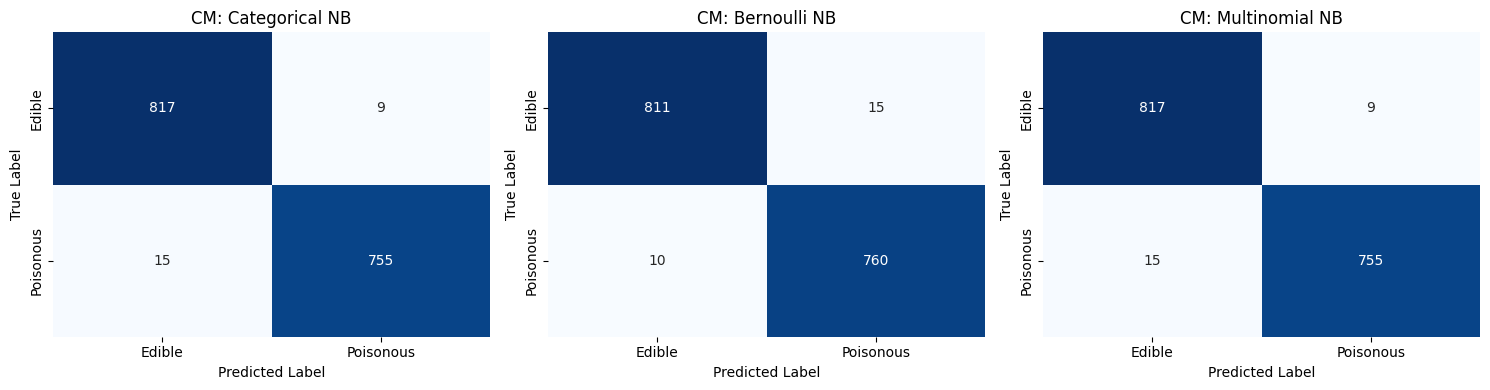

In [114]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds = [
    ("Categorical NB", y_pred_cat),
    ("Bernoulli NB", y_pred_bern),
    ("Multinomial NB", y_pred_multi),
]

for idx, (name, pred) in enumerate(preds):
  cm = confusion_matrix(y_test, pred)
  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues",
      cbar=False,
      ax=axes[idx],
      xticklabels=["Edible", "Poisonous"],
      yticklabels=["Edible", "Poisonous"],
  )
  axes[idx].set_title(f"CM: {name}")
  axes[idx].set_xlabel("Predicted Label")
  axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()

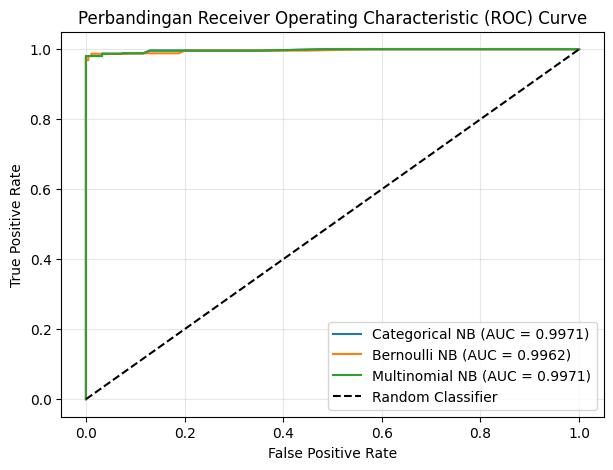

In [115]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(7, 5))
probs = [
    ("Categorical NB", y_prob_cat),
    ("Bernoulli NB", y_prob_bern),
    ("Multinomial NB", y_prob_multi),
]

for name, prob in probs:
  fpr, tpr, _ = roc_curve(y_test, prob)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Perbandingan Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

##Hasil Analisis
Berdasarkan eksperimen yang telah dilakukan pada 1.625 data uji, ketiga model Naive Bayes yaitu Categorical NB, Bernoulli NB, dan Multinomial NB mampu melakukan klasifikasi jamur dengan performa yang cukup tinggi. Perbedaan performa ketiga model berkaitan dengan representasi data yang digunakan pada masing-masing model.

Secara performa, Categorical NB dan Multinomial NB menghasilkan nilai yang sama, yaitu Accuracy sebesar **94,58%**, Precision **99,01%**, Recall **89,66%**, F1-Score **94,10%**, dan ROC-AUC **99,72%**. Sementara itu, Bernoulli NB menghasilkan Accuracy **93,29%**, Precision **98,14%**, Recall **87,74%**, F1-Score **92,65%**, dan ROC-AUC **99,54%**.

Categorical NB menggunakan **Ordinal Encoding**, sehingga setiap kategori pada fitur diubah menjadi nilai numerik. Model ini menghitung probabilitas kemunculan suatu kategori terhadap masing-masing kelas. Hasilnya menunjukkan bahwa model mampu melakukan klasifikasi dengan baik pada data kategorikal yang digunakan.

Multinomial NB menggunakan **One-Hot Encoding**, sehingga setiap kategori direpresentasikan dalam bentuk nilai 0 dan 1. Meskipun representasinya berbeda dengan Categorical NB, hasil pengujian menunjukkan performa yang sama pada seluruh metrik. Hal ini menunjukkan bahwa pada eksperimen ini representasi tersebut tetap dapat digunakan dengan baik oleh Multinomial NB.

Bernoulli NB juga menggunakan **One-Hot Encoding**, tetapi model berfokus pada keberadaan atau ketidakberadaan fitur dalam bentuk biner. Hasilnya sedikit lebih rendah dibandingkan Categorical NB dan Multinomial NB, terutama pada Recall dan F1-Score. Recall sebesar **87,74%** menunjukkan bahwa masih terdapat sebagian data jamur beracun yang diprediksi sebagai jamur yang dapat dimakan.

Berdasarkan hasil tersebut, **Categorical NB dan Multinomial NB memperoleh performa tertinggi dengan hasil yang sama**. Ketiga model juga memiliki nilai ROC-AUC di atas **0,99**, yang menunjukkan bahwa ketiganya memiliki kemampuan yang sangat baik dalam membedakan kelas jamur edible dan poisonous pada data uji yang digunakan.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## Kesimpulan
Dari eksperimen yang telah dilakukan, disimpulkan bahwa:

* **Categorical Naive Bayes** dan **Multinomial Naive Bayes** menghasilkan performa yang sama dan menjadi model dengan hasil evaluasi tertinggi, yaitu *Accuracy* 94,58%, *Precision* 99,01%, *Recall* 89,66%, *F1-Score* 94,10%, dan ROC-AUC 99,72%.
* **Bernoulli Naive Bayes** menghasilkan performa sedikit lebih rendah, yaitu *Accuracy* 93,29%, *Precision* 98,14%, *Recall* 87,74%, *F1-Score* 92,65%, dan ROC-AUC 99,54%.
* Penggunaan representasi data yang berbeda memengaruhi hasil model. Categorical NB menggunakan *Ordinal Encoding*, sedangkan Bernoulli NB dan Multinomial NB menggunakan *One-Hot Encoding*.
* Secara keseluruhan, ketiga model mampu melakukan klasifikasi jamur dengan baik karena seluruh model memperoleh ROC-AUC di atas 0,99.

## Saran
Saran untuk eksperimen selanjutnya:

* Melakukan *cross-validation* untuk mendapatkan evaluasi model yang lebih stabil.
* Mencoba metode *encoding* atau pemilihan fitur lain untuk melihat pengaruhnya terhadap performa model.
* Membandingkan Naive Bayes dengan algoritma klasifikasi lain seperti *Decision Tree* atau *Random Forest*.
* Melakukan analisis lebih lanjut terhadap *False Negative*, yaitu jamur beracun yang salah diprediksi sebagai jamur yang dapat dimakan.